📓**TAREA 1**

**Análisis Exploratorio de Datos (EDA) y Machine Learning Básico
Impacto del uso de Inteligencia Artificial Generativa sobre el rendimiento académico universitario**

**Maestría en Transformación Digital e Innovación**

**Asignatura:** Big Data, Analytics & Data Scientist

**Autor:** Gustavo Fernando Torres Leyva

**Docente:** Ing. Carlos Wladimir Carrillo Villavicencio, MSc.

**Fecha:** Julio 2026

**INDICE**
1. Introducción
2. Objetivos
3. Comprensión del problema (CRISP-DM)
4. Importación de librerías
5. Carga del conjunto de datos
6. Evaluación de la Calidad de los Datos
7. Preparación del dataset
8. Análisis exploratorio de Datos
9. Análisis de Correlación
10. Ingeniería de Características
11. Modelado Predictivo

# Introducción

La Inteligencia Artificial Generativa (IAG) ha transformado significativamente la manera en que los estudiantes acceden al conocimiento, resuelven problemas y desarrollan actividades académicas. Herramientas como ChatGPT, GitHub Copilot y otros asistentes inteligentes han incrementado su presencia dentro de los procesos educativos, generando beneficios relacionados con la productividad y el aprendizaje, pero también nuevos desafíos asociados con la dependencia tecnológica, la ética académica y el desarrollo de competencias críticas.

En este proyecto se desarrolla un Análisis Exploratorio de Datos (EDA) sobre un conjunto de información relacionado con estudiantes universitarios y su interacción con herramientas de Inteligencia Artificial. Posteriormente se implementan modelos básicos de Machine Learning con el propósito de analizar qué variables presentan mayor influencia sobre el rendimiento académico medido mediante el GPA posterior al semestre.

El desarrollo del proyecto sigue las buenas prácticas de Ciencia de Datos propuestas por la metodología CRISP-DM, incluyendo comprensión del problema, comprensión de los datos, preparación, modelado, evaluación e interpretación de resultados.

# Objetivo General

Realizar un análisis exploratorio de datos e implementar un modelo básico de Machine Learning que permita estudiar la relación entre el uso de herramientas de Inteligencia Artificial Generativa y el rendimiento académico de estudiantes universitarios.

# Objetivos Específicos

- Comprender la estructura y calidad del conjunto de datos.
- Aplicar técnicas de limpieza y preparación de datos.
- Realizar un análisis exploratorio utilizando estadísticas descriptivas y visualizaciones.
- Identificar relaciones entre las variables académicas y tecnológicas.
- Implementar y evaluar modelos de regresión para estimar el rendimiento académico.
- Interpretar los resultados obtenidos y proponer recomendaciones fundamentadas.

# Comprensión del problema

## Contexto

La incorporación de herramientas de Inteligencia Artificial Generativa en el ámbito universitario ha modificado las estrategias tradicionales de aprendizaje. Comprender cómo estas herramientas se relacionan con el desempeño académico resulta de interés para estudiantes, docentes e instituciones educativas.

## Problema

Existe incertidumbre respecto a la influencia que tiene el uso de Inteligencia Artificial sobre el rendimiento académico. Aunque estas herramientas facilitan múltiples tareas, no está claro cuáles factores contribuyen realmente al desempeño estudiantil.

## Pregunta de investigación

¿Qué variables asociadas al uso de Inteligencia Artificial presentan mayor influencia sobre el GPA obtenido por los estudiantes al finalizar el semestre?

## Hipótesis

Se plantea que el rendimiento académico depende de una combinación de variables relacionadas con el uso de Inteligencia Artificial, los hábitos de estudio y las características académicas previas del estudiante.

In [1]:
# ==========================================
# Importación de librerías
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.impute import SimpleImputer

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [2]:
# ==========================================
# Configuración
# ==========================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")

RANDOM_STATE = 42

print("Configuración aplicada.")

Configuración aplicada.


# Carga del conjunto de datos

En esta sección se carga el archivo CSV y se verifica que la información haya sido importada correctamente antes de iniciar el análisis exploratorio.

In [4]:
# Lectura del archivo

df = pd.read_csv("ai_student_impact_dataset.csv")

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


*Realizaremos una exploración rápida de los primeros y últimos registros*

In [5]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [6]:
df.tail()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium
49999,150000,Arts,Sophomore,3.242,3.30,Copywriting/Drafting,Beginner,1,False,3.93,2,Allowed_With_Citation,6,3.261,76.16,Low


Vamos a proceder con el Análisis Exploratorio

In [16]:
# Dimensiones
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 50000
Columnas: 16


In [17]:
# Nombres de variables
df.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='object')

In [18]:
#Tipos de Datos
df.dtypes

,0
Student_ID,int64
Major_Category,object
Year_of_Study,object
Pre_Semester_GPA,float64
Weekly_GenAI_Hours,float64
Primary_Use_Case,object
Prompt_Engineering_Skill,object
Tool_Diversity,int64
Paid_Subscription,bool
Traditional_Study_Hours,float64


In [19]:
# Información General
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [20]:
# Estadística Descriptiva
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Student_ID,50000.0,125000.500000,14433.901067,100001.000,112500.75000,125000.500,137500.250,150000.000
Pre_Semester_GPA,50000.0,3.146102,0.478854,1.183,2.83400,3.210,3.521,3.998
Weekly_GenAI_Hours,50000.0,8.427752,8.269490,0.000,2.39000,5.800,11.720,40.000
Tool_Diversity,50000.0,2.800260,1.188020,1.000,2.00000,3.000,4.000,5.000
Traditional_Study_Hours,50000.0,11.209271,5.156426,1.000,7.56000,11.180,14.710,35.860
Perceived_AI_Dependency,50000.0,3.505360,1.820812,1.000,2.00000,3.000,5.000,10.000
Anxiety_Level_During_Exams,50000.0,4.270760,2.144066,1.000,3.00000,4.000,6.000,10.000
Post_Semester_GPA,50000.0,3.349299,0.495673,1.000,3.02375,3.421,3.749,4.000
Skill_Retention_Score,50000.0,75.798125,13.281626,10.780,66.82000,76.000,85.190,100.000


In [21]:
# Variables Categóricas
df.describe(include="object").T

,count,unique,top,freq
Major_Category,50000,5,STEM,15059
Year_of_Study,50000,5,Junior,11045
Primary_Use_Case,50000,5,Debugging/Troubleshooting,12295
Prompt_Engineering_Skill,50000,3,Beginner,18495
Institutional_Policy,50000,3,Allowed_With_Citation,25224
Burnout_Risk_Level,50000,3,Medium,21144


In [22]:
# Muestra Aleatoria
df.sample(10, random_state=RANDOM_STATE)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
33553,133554,STEM,Graduate,2.208,1.75,Direct_Answer_Generation,Intermediate,1,True,8.22,2,Actively_Encouraged,2,2.582,64.42,Low
9427,109428,Arts,Graduate,2.931,3.08,Ideation,Beginner,3,True,11.68,5,Actively_Encouraged,8,3.452,82.34,Low
199,100200,Arts,Sophomore,2.874,14.28,Direct_Answer_Generation,Advanced,3,False,13.68,6,Strict_Ban,5,3.035,87.08,High
12447,112448,Medical,Junior,2.517,7.42,Copywriting/Drafting,Beginner,1,True,1.00,1,Allowed_With_Citation,1,2.754,78.94,High
39489,139490,Business,Sophomore,2.927,3.12,Copywriting/Drafting,Intermediate,3,False,5.59,3,Actively_Encouraged,4,3.084,63.73,Low
42724,142725,Business,Freshman,3.830,3.61,Copywriting/Drafting,Beginner,3,True,15.50,2,Allowed_With_Citation,3,3.725,82.04,Low
10822,110823,Medical,Graduate,2.404,3.25,Direct_Answer_Generation,Beginner,1,False,9.16,4,Allowed_With_Citation,2,3.032,56.49,High
49498,149499,Humanities,Freshman,3.385,13.92,Summarizing_Reading,Intermediate,3,False,11.98,4,Allowed_With_Citation,8,3.392,66.91,High
4144,104145,Medical,Senior,3.014,3.24,Ideation,Beginner,2,False,10.18,3,Allowed_With_Citation,4,3.227,90.19,Low
36958,136959,STEM,Freshman,2.847,7.48,Debugging/Troubleshooting,Beginner,1,False,8.40,4,Strict_Ban,3,3.024,67.21,Low


In [23]:
# Uso de Memoria
df.memory_usage(deep=True)

,0
Index,132
Student_ID,400000
Major_Category,2779544
Year_of_Study,2816502
Pre_Semester_GPA,400000
Weekly_GenAI_Hours,400000
Primary_Use_Case,3399550
Prompt_Engineering_Skill,2920784
Tool_Diversity,400000
Paid_Subscription,50000


In [24]:
# Número de casos únicos
df.nunique().sort_values(ascending=False)

,0
Student_ID,50000
Skill_Retention_Score,5872
Weekly_GenAI_Hours,3566
Traditional_Study_Hours,2516
Pre_Semester_GPA,2389
Post_Semester_GPA,2269
Perceived_AI_Dependency,10
Anxiety_Level_During_Exams,10
Major_Category,5
Tool_Diversity,5


## Conclusión de la exploración inicial

La revisión preliminar del conjunto de datos permitió verificar que la información fue cargada correctamente y que las variables presentan una combinación de datos numéricos y categóricos, adecuados para desarrollar un análisis exploratorio completo.

Asimismo, la inspección inicial facilita la identificación de las variables que posteriormente serán utilizadas en el proceso de limpieza, visualización y construcción de modelos de Machine Learning.

# Evaluación de la Calidad de los Datos

Antes de realizar cualquier análisis estadístico o construir modelos predictivos, es fundamental evaluar la calidad del conjunto de datos. Esta etapa permite detectar posibles problemas como valores faltantes, registros duplicados, inconsistencias en los tipos de datos o valores atípicos que puedan afectar la confiabilidad de los resultados.

En esta sección se realiza una revisión sistemática de la estructura del dataset utilizando diferentes funciones de Pandas.

In [25]:
# Dimensiones del conjunto de datos

filas, columnas = df.shape

print("="*60)
print("DIMENSIONES DEL DATASET")
print("="*60)
print(f"Número de filas      : {filas:,}")
print(f"Número de columnas   : {columnas}")

DIMENSIONES DEL DATASET
Número de filas      : 50,000
Número de columnas   : 16


In [26]:
print("="*60)
print("INFORMACIÓN GENERAL")
print("="*60)

df.info()

INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semest

In [27]:
# Tipo de Datos
tipos = pd.DataFrame({
    "Variable": df.columns,
    "Tipo": df.dtypes.values
})

tipos

,Variable,Tipo
0,Student_ID,int64
1,Major_Category,object
2,Year_of_Study,object
3,Pre_Semester_GPA,float64
4,Weekly_GenAI_Hours,float64
5,Primary_Use_Case,object
6,Prompt_Engineering_Skill,object
7,Tool_Diversity,int64
8,Paid_Subscription,bool
9,Traditional_Study_Hours,float64


In [29]:
# Valores Nulos
# Valores faltantes

nulos = pd.DataFrame({
    "Valores Nulos": df.isnull().sum(),
    "Porcentaje (%)": round(df.isnull().mean()*100,2)
})

nulos.sort_values(
    by="Valores Nulos",
    ascending=False
)

,Valores Nulos,Porcentaje (%)
Student_ID,0,0.0
Major_Category,0,0.0
Year_of_Study,0,0.0
Pre_Semester_GPA,0,0.0
Weekly_GenAI_Hours,0,0.0
Primary_Use_Case,0,0.0
Prompt_Engineering_Skill,0,0.0
Tool_Diversity,0,0.0
Paid_Subscription,0,0.0
Traditional_Study_Hours,0,0.0


Si todas las variables presentan cero valores nulos, el conjunto de datos puede considerarse completo para efectos del análisis. En caso contrario, será necesario evaluar estrategias de imputación o eliminación dependiendo del porcentaje de información faltante.

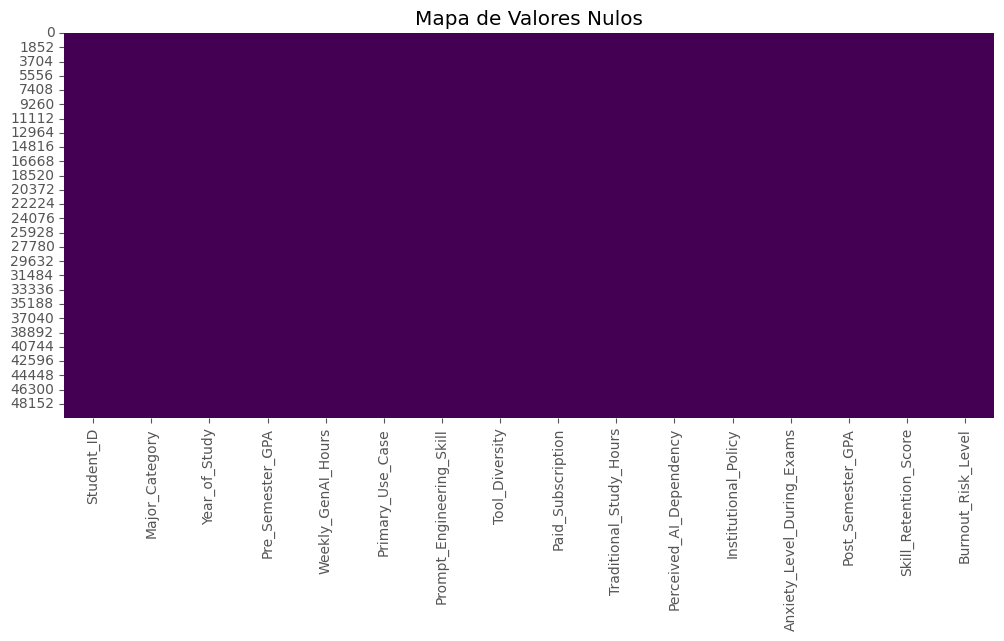

In [31]:
# Mapa de Valores Nulos
plt.figure(figsize=(12,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Mapa de Valores Nulos")
plt.show()

In [32]:
# Registros Duplicados
duplicados = df.duplicated().sum()

print("="*60)
print("REGISTROS DUPLICADOS")
print("="*60)

print(duplicados)

REGISTROS DUPLICADOS
0


In [33]:
# Limpieza de Registros Duplicados (Si existieran)
if duplicados > 0:
    df = df.drop_duplicates()
    print("Duplicados eliminados.")
else:
    print("No existen registros duplicados.")

No existen registros duplicados.


In [34]:
# Número de valores únicos
unicos = pd.DataFrame({
    "Valores Únicos": df.nunique()
})

unicos.sort_values(
    by="Valores Únicos",
    ascending=False
)

,Valores Únicos
Student_ID,50000
Skill_Retention_Score,5872
Weekly_GenAI_Hours,3566
Traditional_Study_Hours,2516
Pre_Semester_GPA,2389
Post_Semester_GPA,2269
Perceived_AI_Dependency,10
Anxiety_Level_During_Exams,10
Major_Category,5
Tool_Diversity,5


In [35]:
# Distribución de Tipo de Datos
df.dtypes.value_counts()

,count
object,6
float64,5
int64,4
bool,1


In [37]:
# Identificación de Variables Numéricas
variables_numericas = df.select_dtypes(
    include=np.number
).columns.tolist()

variables_numericas

['Student_ID',
 'Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Tool_Diversity',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Anxiety_Level_During_Exams',
 'Post_Semester_GPA',
 'Skill_Retention_Score']

In [38]:
# Identificación de Variables Categóricas
variables_categoricas = df.select_dtypes(
    exclude=np.number
).columns.tolist()

variables_categoricas

['Major_Category',
 'Year_of_Study',
 'Primary_Use_Case',
 'Prompt_Engineering_Skill',
 'Paid_Subscription',
 'Institutional_Policy',
 'Burnout_Risk_Level']

In [39]:
# Estadísticas Descriptivas
estadisticas = df.describe().T

estadisticas

,count,mean,std,min,25%,50%,75%,max
Student_ID,50000.0,125000.500000,14433.901067,100001.000,112500.75000,125000.500,137500.250,150000.000
Pre_Semester_GPA,50000.0,3.146102,0.478854,1.183,2.83400,3.210,3.521,3.998
Weekly_GenAI_Hours,50000.0,8.427752,8.269490,0.000,2.39000,5.800,11.720,40.000
Tool_Diversity,50000.0,2.800260,1.188020,1.000,2.00000,3.000,4.000,5.000
Traditional_Study_Hours,50000.0,11.209271,5.156426,1.000,7.56000,11.180,14.710,35.860
Perceived_AI_Dependency,50000.0,3.505360,1.820812,1.000,2.00000,3.000,5.000,10.000
Anxiety_Level_During_Exams,50000.0,4.270760,2.144066,1.000,3.00000,4.000,6.000,10.000
Post_Semester_GPA,50000.0,3.349299,0.495673,1.000,3.02375,3.421,3.749,4.000
Skill_Retention_Score,50000.0,75.798125,13.281626,10.780,66.82000,76.000,85.190,100.000


In [40]:
# Estadísticas de Variables Categóricas
df.describe(include="object").T

,count,unique,top,freq
Major_Category,50000,5,STEM,15059
Year_of_Study,50000,5,Junior,11045
Primary_Use_Case,50000,5,Debugging/Troubleshooting,12295
Prompt_Engineering_Skill,50000,3,Beginner,18495
Institutional_Policy,50000,3,Allowed_With_Citation,25224
Burnout_Risk_Level,50000,3,Medium,21144


In [41]:
# Consumo de Memoria
memoria = (
    df.memory_usage(deep=True)
      .sort_values(ascending=False)
)

memoria

,0
Primary_Use_Case,3399550
Institutional_Policy,3362356
Prompt_Engineering_Skill,2920784
Year_of_Study,2816502
Major_Category,2779544
Burnout_Risk_Level,2675919
Tool_Diversity,400000
Pre_Semester_GPA,400000
Student_ID,400000
Post_Semester_GPA,400000


In [42]:
# Frecuencia de Variables Categóricas
for columna in variables_categoricas:

    print("="*60)
    print(columna)
    print("="*60)

    print(df[columna].value_counts())

    print()

Major_Category
Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

Year_of_Study
Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64

Primary_Use_Case
Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64

Prompt_Engineering_Skill
Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64

Paid_Subscription
Paid_Subscription
False    28846
True     21154
Name: count, dtype: int64

Institutional_Policy
Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64

Burnout_Risk_Level
Burnout_Risk_Level
Medium    21144
Low  

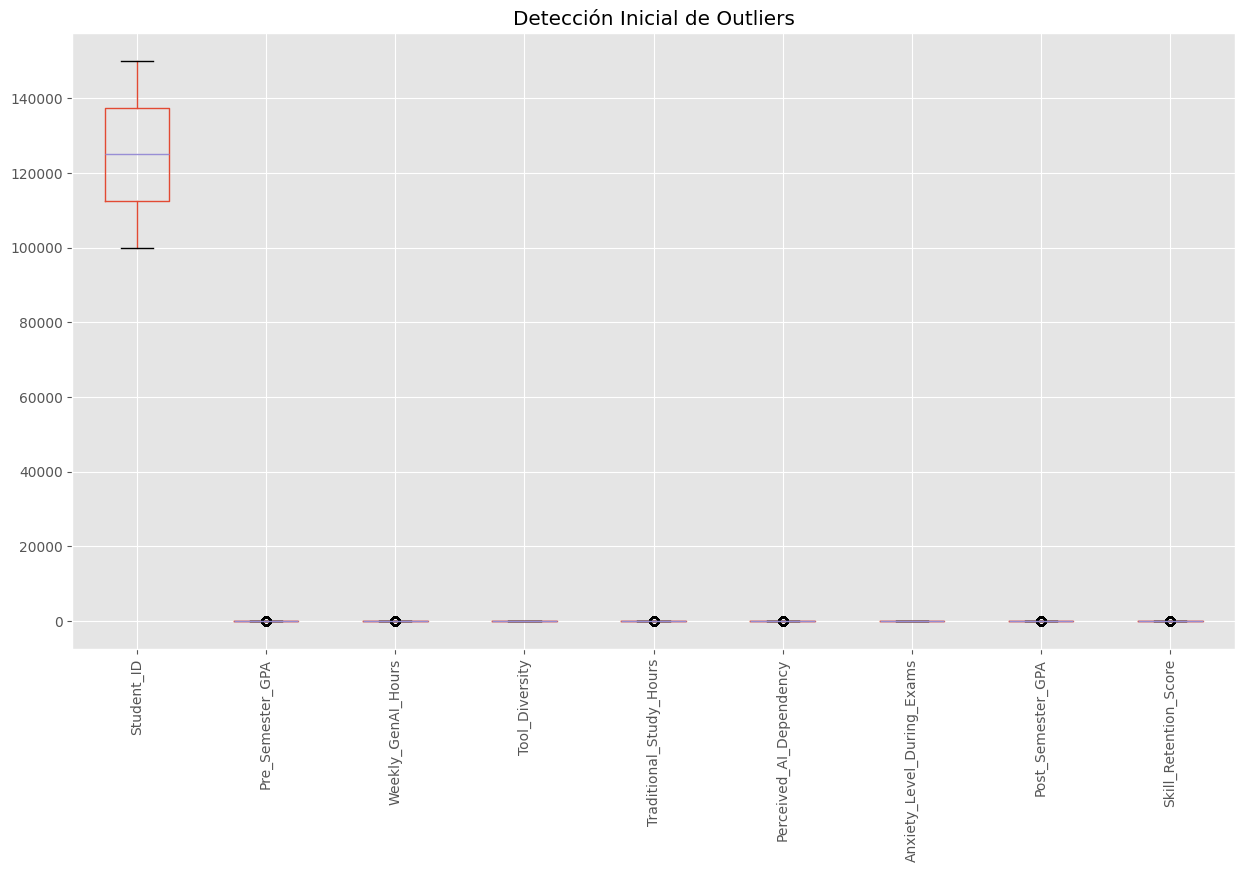

In [44]:
# Detección de Valores Atípicos
plt.figure(figsize=(15,8))

df[variables_numericas].boxplot(rot=90)

plt.title("Detección Inicial de Outliers")

plt.show()

# Preparación del Dataset

Una vez verificada la calidad del conjunto de datos, se procede a realizar las transformaciones necesarias para facilitar el análisis exploratorio y el entrenamiento de modelos predictivos.

Las actividades desarrolladas incluyen:

- Revisión de nombres de columnas.
- Conversión de tipos de datos.
- Creación de variables auxiliares cuando sea necesario.
- Preparación para la codificación de variables categóricas.

In [46]:
# Renombrar Columnas (En caso de requerir un modelado adaptable)
df.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='object')

In [48]:
# Conversión de Categorías
for col in variables_categoricas:
    df[col] = df[col].astype("category")

In [49]:
# Verificación
df.dtypes

,0
Student_ID,int64
Major_Category,category
Year_of_Study,category
Pre_Semester_GPA,float64
Weekly_GenAI_Hours,float64
Primary_Use_Case,category
Prompt_Engineering_Skill,category
Tool_Diversity,int64
Paid_Subscription,category
Traditional_Study_Hours,float64


In [50]:
# Ordenar El Dataset
df = df.sort_values(
    by="Post_Semester_GPA",
    ascending=False
)

In [51]:
# Filtrado de Información
alto_rendimiento = df.query(
    "Post_Semester_GPA >= 3.5"
)

alto_rendimiento.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
49979,149980,Business,Senior,3.750,16.00,Ideation,Beginner,1,True,7.00,3,Allowed_With_Citation,1,4.0,66.12,Low
49976,149977,Business,Graduate,3.692,7.31,Summarizing_Reading,Beginner,3,False,18.38,5,Actively_Encouraged,5,4.0,66.81,Medium
29,100030,STEM,Sophomore,3.638,12.83,Debugging/Troubleshooting,Advanced,4,True,10.25,5,Allowed_With_Citation,4,4.0,61.29,Medium
25,100026,Arts,Senior,3.308,2.38,Ideation,Advanced,4,True,11.33,2,Actively_Encouraged,2,4.0,81.85,High
49950,149951,Humanities,Freshman,3.848,3.64,Copywriting/Drafting,Intermediate,4,False,12.23,1,Allowed_With_Citation,4,4.0,79.59,Low


In [52]:
# Creación de Variable Derivada
df = df.assign(
    GPA_Improvement=
    df["Post_Semester_GPA"]-
    df["Pre_Semester_GPA"]
)

df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,GPA_Improvement
49979,149980,Business,Senior,3.750,16.00,Ideation,Beginner,1,True,7.00,3,Allowed_With_Citation,1,4.0,66.12,Low,0.250
49976,149977,Business,Graduate,3.692,7.31,Summarizing_Reading,Beginner,3,False,18.38,5,Actively_Encouraged,5,4.0,66.81,Medium,0.308
29,100030,STEM,Sophomore,3.638,12.83,Debugging/Troubleshooting,Advanced,4,True,10.25,5,Allowed_With_Citation,4,4.0,61.29,Medium,0.362
25,100026,Arts,Senior,3.308,2.38,Ideation,Advanced,4,True,11.33,2,Actively_Encouraged,2,4.0,81.85,High,0.692
49950,149951,Humanities,Freshman,3.848,3.64,Copywriting/Drafting,Intermediate,4,False,12.23,1,Allowed_With_Citation,4,4.0,79.59,Low,0.152


In [55]:
# Selección Mediante loc
df.loc[
    :,
    [
        "Pre_Semester_GPA",
        "Post_Semester_GPA",
        "Weekly_GenAI_Hours"
    ]
].head()

,Pre_Semester_GPA,Post_Semester_GPA,Weekly_GenAI_Hours
49979,3.750,4.0,16.00
49976,3.692,4.0,7.31
29,3.638,4.0,12.83
25,3.308,4.0,2.38
49950,3.848,4.0,3.64


In [56]:
# Selección Mediante iloc
df.iloc[
    0:10,
    0:6
]

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case
49979,149980,Business,Senior,3.750,16.00,Ideation
49976,149977,Business,Graduate,3.692,7.31,Summarizing_Reading
29,100030,STEM,Sophomore,3.638,12.83,Debugging/Troubleshooting
25,100026,Arts,Senior,3.308,2.38,Ideation
49950,149951,Humanities,Freshman,3.848,3.64,Copywriting/Drafting
49944,149945,STEM,Junior,3.676,13.38,Debugging/Troubleshooting
49931,149932,Humanities,Graduate,3.651,15.49,Summarizing_Reading
49930,149931,STEM,Junior,3.822,2.28,Summarizing_Reading
49897,149898,Business,Freshman,3.963,8.99,Summarizing_Reading
49893,149894,Medical,Freshman,3.541,19.37,Summarizing_Reading


In [57]:
# Agrupación
df.groupby(
    "Major_Category"
)["Post_Semester_GPA"].mean().sort_values(
    ascending=False
)

,Post_Semester_GPA
Major_Category,
STEM,3.363154
Medical,3.353168
Humanities,3.345825
Arts,3.343688
Business,3.336085


In [58]:
# Agregaciones
df.groupby(
    "Major_Category"
)["Post_Semester_GPA"].mean().sort_values(
    ascending=False
)

,Post_Semester_GPA
Major_Category,
STEM,3.363154
Medical,3.353168
Humanities,3.345825
Arts,3.343688
Business,3.336085


In [59]:
# Tabla Dinámica
pd.pivot_table(

    df,

    values="Post_Semester_GPA",

    index="Major_Category",

    columns="Prompt_Engineering_Skill",

    aggfunc="mean"

)

Prompt_Engineering_Skill,Advanced,Beginner,Intermediate
Major_Category,,,
Arts,3.379955,3.323165,3.340424
Business,3.365201,3.324734,3.328608
Humanities,3.373182,3.340953,3.332269
Medical,3.392588,3.345269,3.332335
STEM,3.412472,3.338945,3.337389


In [65]:
# Tabla cruzada
pd.crosstab(

    df["Major_Category"],

    df["Paid_Subscription"]

)

Paid_Subscription,False,True
Major_Category,,
Arts,3500,2433
Business,7304,5234
Humanities,6007,3987
Medical,3860,2616
STEM,8175,6884


In [66]:
# Correlación
correlacion = df.corr(
    numeric_only=True
)

correlacion

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,GPA_Improvement
Student_ID,1.000000,0.002275,0.001577,-0.001187,0.000648,0.002768,0.009670,-0.000602,-0.001737,-0.007413
Pre_Semester_GPA,0.002275,1.000000,-0.001084,-0.005671,-0.004620,0.000701,-0.000667,0.926781,0.099019,-0.104035
Weekly_GenAI_Hours,0.001577,-0.001084,1.000000,0.008411,-0.157368,0.665479,0.269080,-0.018600,-0.118099,-0.046479
Tool_Diversity,-0.001187,-0.005671,0.008411,1.000000,0.003565,0.006019,0.003189,0.025265,0.196952,0.081407
Traditional_Study_Hours,0.000648,-0.004620,-0.157368,0.003565,1.000000,-0.102625,-0.040935,0.137653,0.147565,0.376317
Perceived_AI_Dependency,0.002768,0.000701,0.665479,0.006019,-0.102625,1.000000,0.307620,-0.014180,-0.084324,-0.039342
Anxiety_Level_During_Exams,0.009670,-0.000667,0.269080,0.003189,-0.040935,0.307620,1.000000,-0.015909,-0.041556,-0.040420
Post_Semester_GPA,-0.000602,0.926781,-0.018600,0.025265,0.137653,-0.014180,-0.015909,1.000000,0.169616,0.277146
Skill_Retention_Score,-0.001737,0.099019,-0.118099,0.196952,0.147565,-0.084324,-0.041556,0.169616,1.000000,0.195833
GPA_Improvement,-0.007413,-0.104035,-0.046479,0.081407,0.376317,-0.039342,-0.040420,0.277146,0.195833,1.000000


## Conclusiones de la Preparación de Datos

La evaluación del conjunto de datos permitió verificar que la información presenta una estructura consistente para el desarrollo del proyecto. Se identificaron las variables numéricas y categóricas, se verificó la existencia de valores nulos y registros duplicados, y se realizaron transformaciones básicas para facilitar el análisis posterior.

Asimismo, se aplicaron diversas operaciones de manipulación utilizando Pandas, incluyendo filtrado, agrupaciones, tablas dinámicas, cruces de variables y creación de nuevas características. Estas actividades permiten disponer de un conjunto de datos preparado para el desarrollo del análisis exploratorio y la construcción de modelos de Machine Learning.

# Análisis Exploratorio de Datos

Una vez preparado el conjunto de datos, se inicia el Análisis Exploratorio de Datos (EDA), cuyo objetivo es comprender el comportamiento de las variables, identificar patrones, detectar relaciones y generar evidencia para la construcción del modelo predictivo.

En esta sección se utilizarán estadísticas descriptivas y visualizaciones que permitirán responder la pregunta de investigación planteada.

In [67]:
# ==========================================
# Configuración de gráficos
# ==========================================

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

sns.set_theme(style="whitegrid")

In [69]:
# Función para Estadísticas
def resumen_variable(columna):

    print("="*70)
    print(f"Variable: {columna}")
    print("="*70)

    print(f"Media: {df[columna].mean():.2f}")
    print(f"Mediana: {df[columna].median():.2f}")
    print(f"Moda: {df[columna].mode()[0]}")
    print(f"Desv. Estándar: {df[columna].std():.2f}")
    print(f"Mínimo: {df[columna].min():.2f}")
    print(f"Máximo: {df[columna].max():.2f}")

    display(df[columna].describe())

In [70]:
# Función para Histogramas
def histograma(variable):

    plt.figure(figsize=(9,5))

    sns.histplot(
        data=df,
        x=variable,
        kde=True,
        bins=30
    )

    plt.title(f"Distribución de {variable}")

    plt.show()


In [71]:
# Función para BloxSplots
def boxplot(variable):

    plt.figure(figsize=(8,4))

    sns.boxplot(
        data=df,
        x=variable
    )

    plt.title(f"Boxplot de {variable}")

    plt.show()


In [72]:
# Función para Código de Barras
def barras(variable):

    plt.figure(figsize=(10,5))

    sns.countplot(
        data=df,
        x=variable,
        order=df[variable].value_counts().index
    )

    plt.xticks(rotation=45)

    plt.title(variable)

    plt.show()

In [73]:
## ESTADISTICA DESCRIPTIVA
resumen_variable("Post_Semester_GPA")

Variable: Post_Semester_GPA
Media: 3.35
Mediana: 3.42
Moda: 4.0
Desv. Estándar: 0.50
Mínimo: 1.00
Máximo: 4.00


,Post_Semester_GPA
count,50000.000000
mean,3.349299
std,0.495673
min,1.000000
25%,3.023750
50%,3.421000
75%,3.749000
max,4.000000


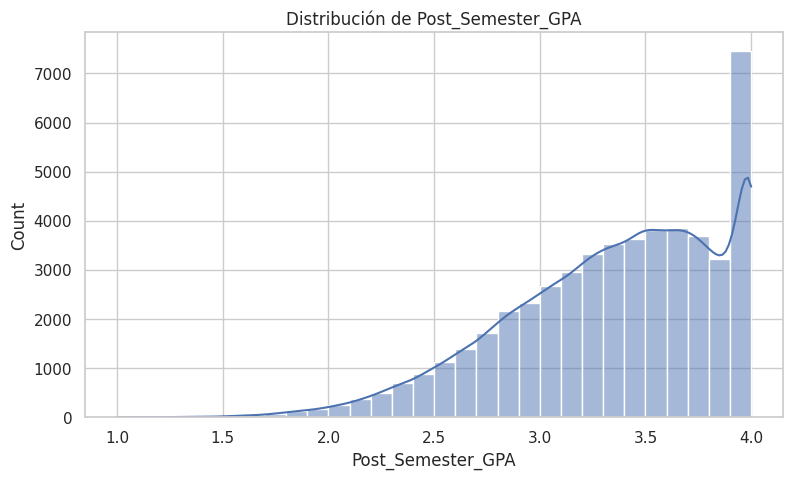

In [74]:
histograma("Post_Semester_GPA")

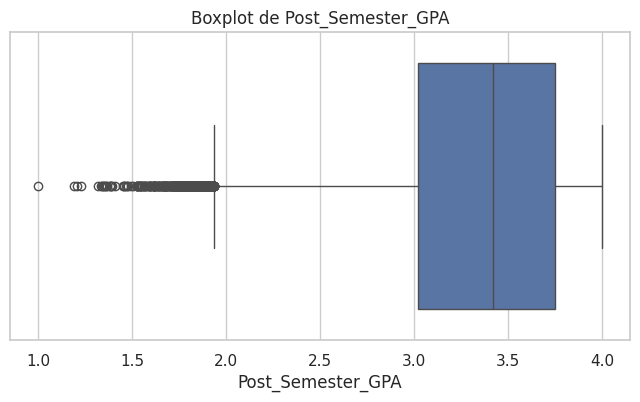

In [75]:
boxplot("Post_Semester_GPA")

### Interpretación

El GPA posterior al semestre presenta una distribución que permite identificar el comportamiento general del rendimiento académico de los estudiantes. La concentración de observaciones alrededor de la media indica que la mayoría de los estudiantes obtuvo un desempeño similar, mientras que los valores extremos representan casos particulares que deben analizarse con mayor detalle.

In [78]:
## HORAS DE USO DE IA

resumen_variable("Weekly_GenAI_Hours")

Variable: Weekly_GenAI_Hours
Media: 8.43
Mediana: 5.80
Moda: 40.0
Desv. Estándar: 8.27
Mínimo: 0.00
Máximo: 40.00


,Weekly_GenAI_Hours
count,50000.000000
mean,8.427752
std,8.269490
min,0.000000
25%,2.390000
50%,5.800000
75%,11.720000
max,40.000000


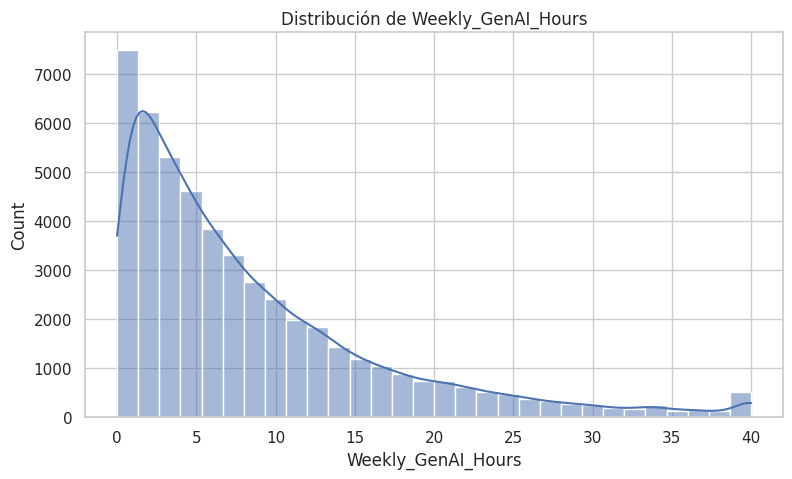

In [79]:
histograma("Weekly_GenAI_Hours")

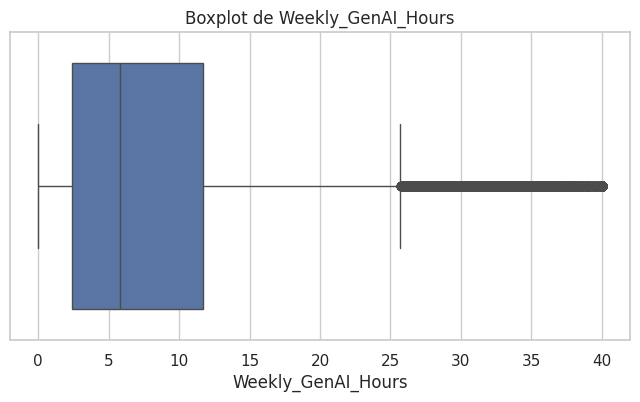

In [80]:
boxplot("Weekly_GenAI_Hours")

Las horas dedicadas al uso de herramientas de Inteligencia Artificial presentan una mayor dispersión que el GPA, lo que evidencia distintos niveles de adopción tecnológica entre los estudiantes analizados.

In [82]:
# Horas de estudio tradicional
resumen_variable("Traditional_Study_Hours")

Variable: Traditional_Study_Hours
Media: 11.21
Mediana: 11.18
Moda: 1.0
Desv. Estándar: 5.16
Mínimo: 1.00
Máximo: 35.86


,Traditional_Study_Hours
count,50000.000000
mean,11.209271
std,5.156426
min,1.000000
25%,7.560000
50%,11.180000
75%,14.710000
max,35.860000


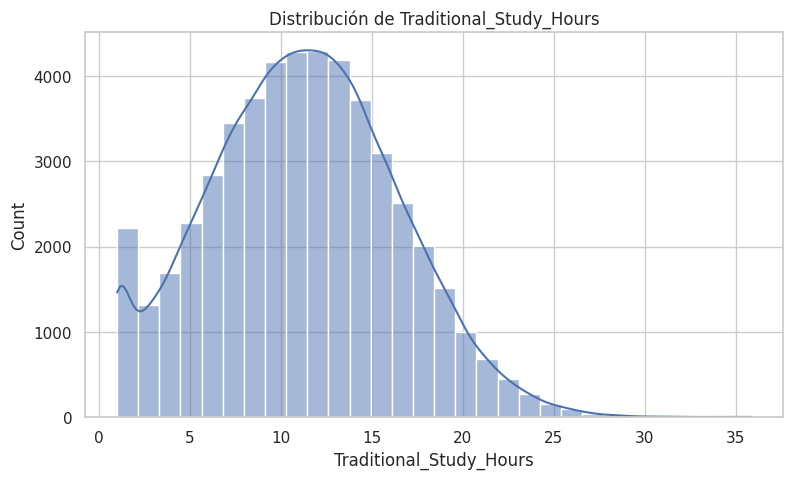

In [83]:
histograma("Traditional_Study_Hours")

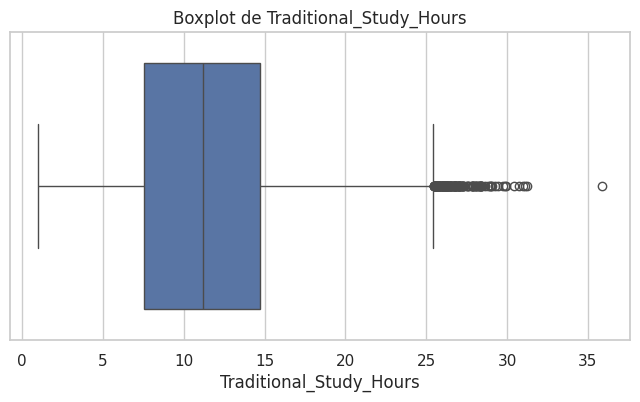

In [84]:
boxplot("Traditional_Study_Hours")

In [85]:
# GPA Antes del Semestre
resumen_variable("Pre_Semester_GPA")

Variable: Pre_Semester_GPA
Media: 3.15
Mediana: 3.21
Moda: 3.433
Desv. Estándar: 0.48
Mínimo: 1.18
Máximo: 4.00


,Pre_Semester_GPA
count,50000.000000
mean,3.146102
std,0.478854
min,1.183000
25%,2.834000
50%,3.210000
75%,3.521000
max,3.998000


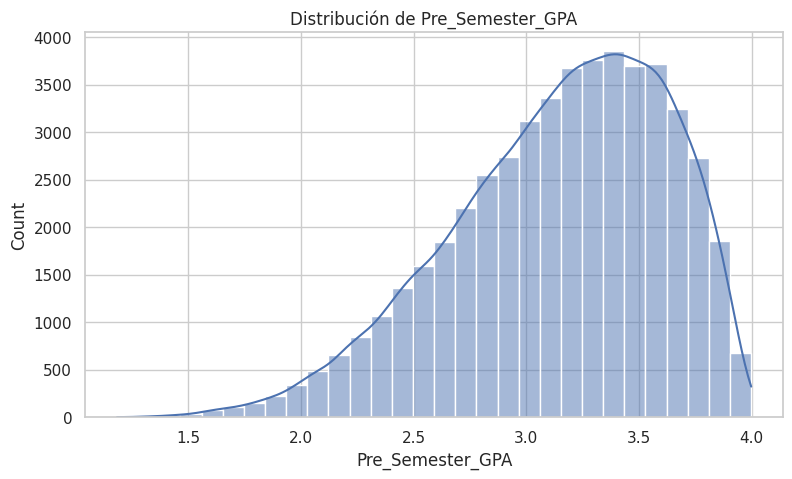

In [86]:
histograma("Pre_Semester_GPA")

In [87]:
# Retención del Aprendizaje
resumen_variable("Skill_Retention_Score")

Variable: Skill_Retention_Score
Media: 75.80
Mediana: 76.00
Moda: 100.0
Desv. Estándar: 13.28
Mínimo: 10.78
Máximo: 100.00


,Skill_Retention_Score
count,50000.000000
mean,75.798125
std,13.281626
min,10.780000
25%,66.820000
50%,76.000000
75%,85.190000
max,100.000000


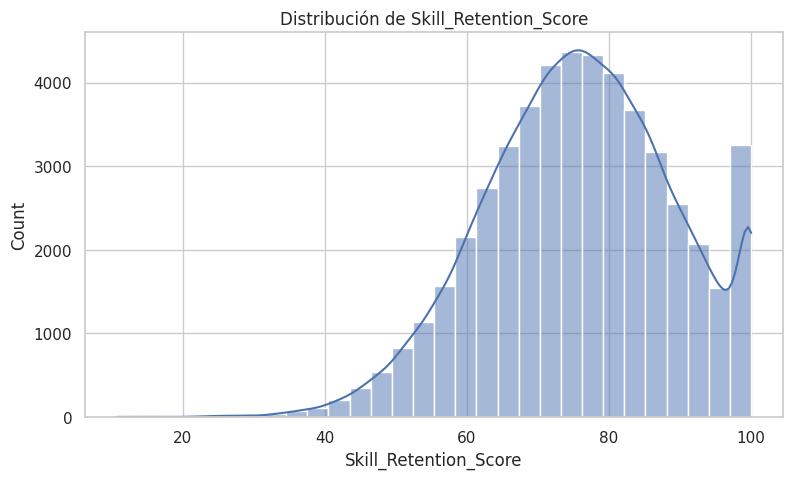

In [88]:
histograma("Skill_Retention_Score")

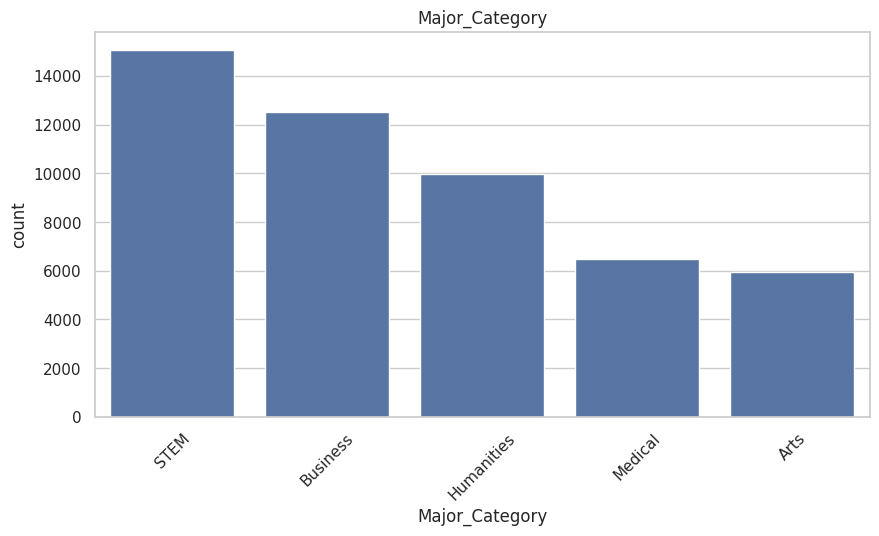

In [90]:
## ANALISIS DE VARIABLES CATEGÓRICAS
# Carrera
barras("Major_Category")

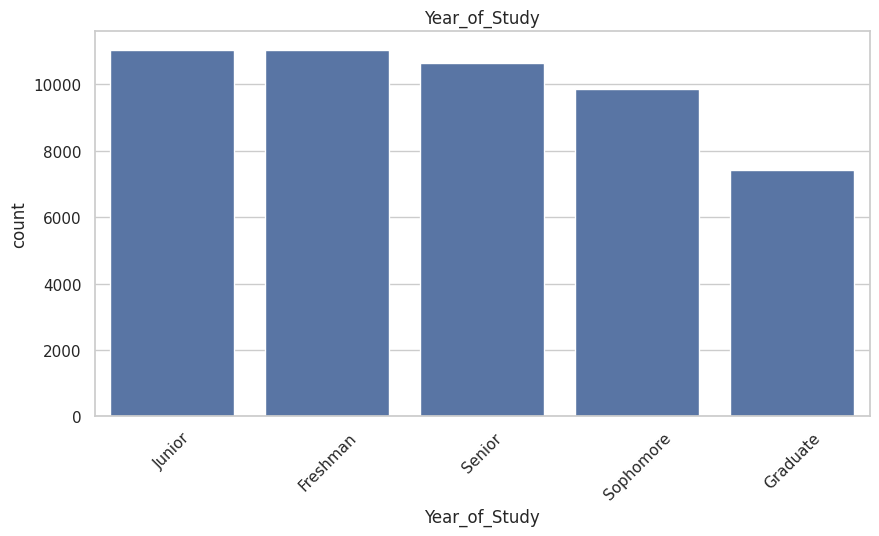

In [91]:
barras("Year_of_Study")


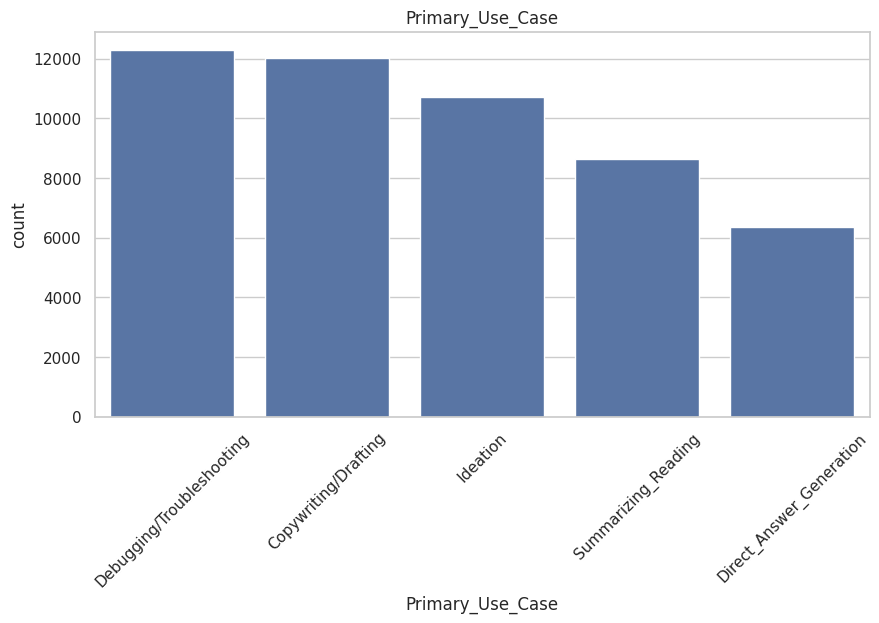

In [92]:
# Uso Principal de la IA
barras("Primary_Use_Case")

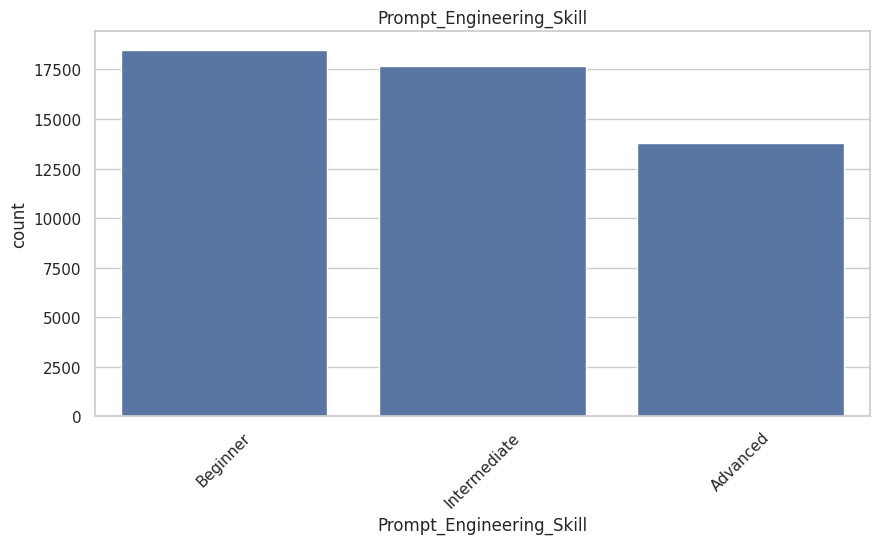

In [93]:
# Nivel de Prompt Engineering
barras("Prompt_Engineering_Skill")

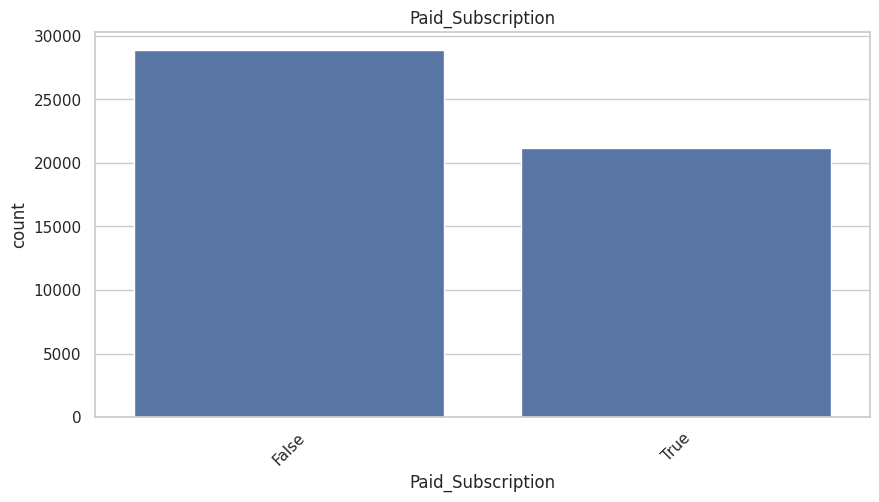

In [94]:
# Suscripción Premium
barras("Paid_Subscription")

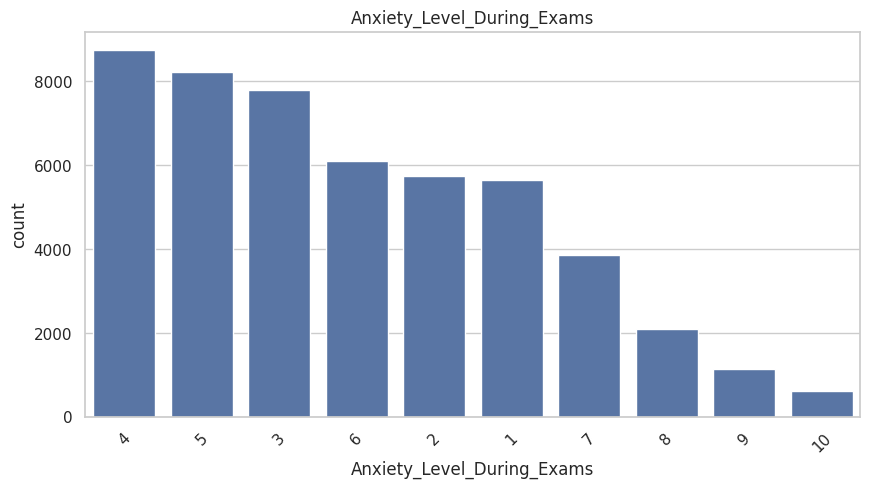

In [95]:
# Nivel de Ansiedad
barras("Anxiety_Level_During_Exams")

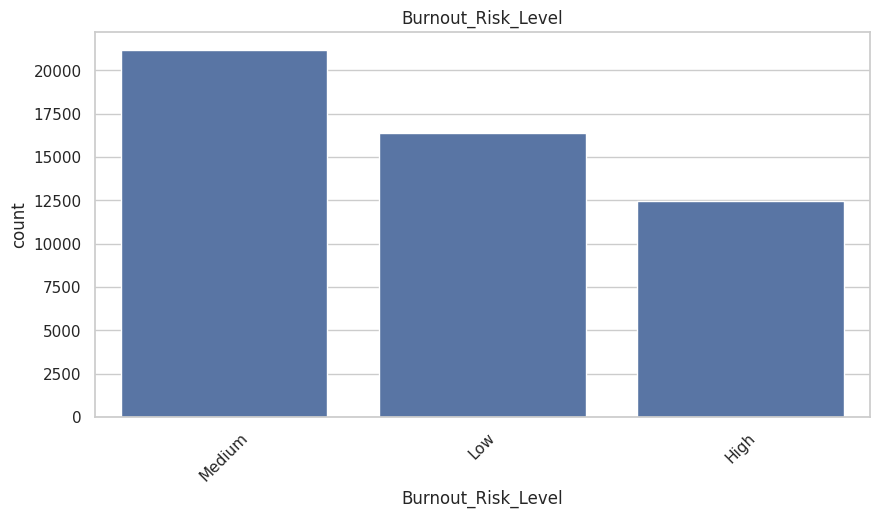

In [96]:
# Riesgo de Bornout
barras("Burnout_Risk_Level")

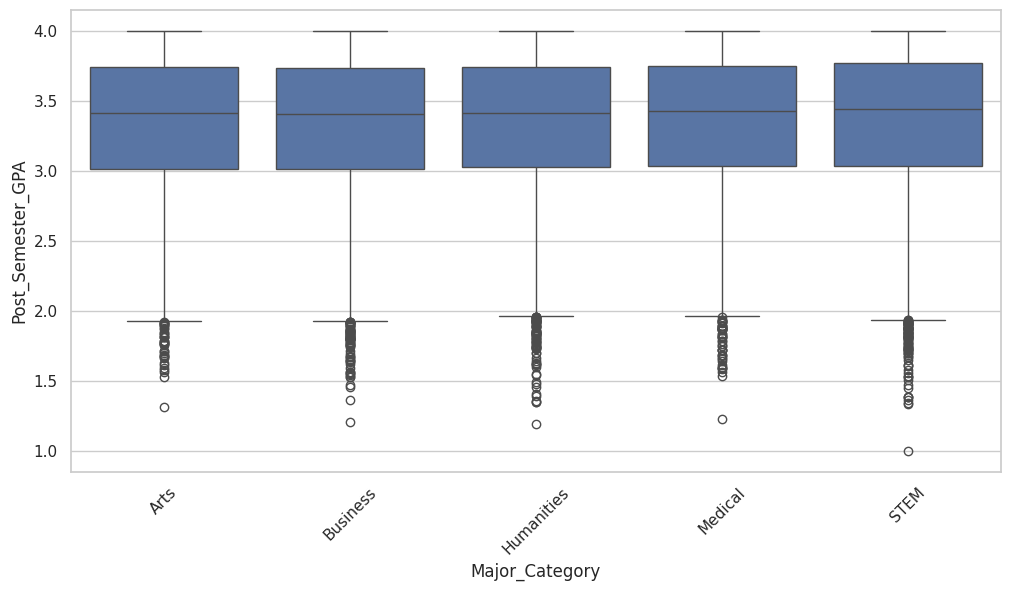

In [97]:
## COMPARACIONES
# Según Carrera

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Major_Category",
    y="Post_Semester_GPA"
)

plt.xticks(rotation=45)

plt.show()

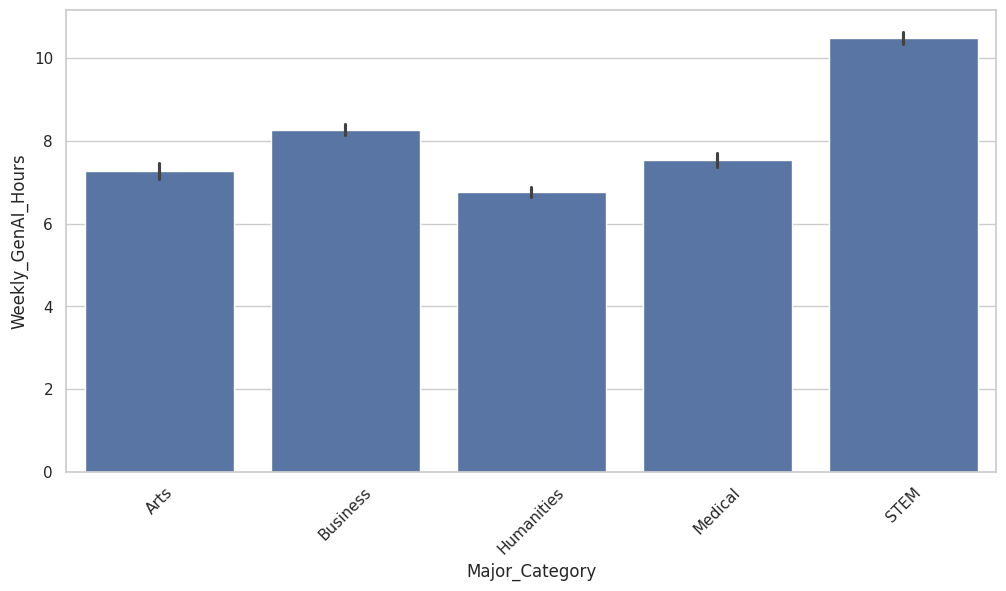

In [99]:
# Horas de Uso de IA por Carrera
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="Major_Category",
    y="Weekly_GenAI_Hours"
)

plt.xticks(rotation=45)

plt.show()

## Conclusiones parciales

El análisis exploratorio permitió identificar diferencias importantes entre los estudiantes en cuanto al tiempo dedicado al uso de herramientas de Inteligencia Artificial, las horas de estudio tradicional y el rendimiento académico obtenido al finalizar el semestre.

Las variables categóricas muestran una distribución equilibrada que facilita posteriores comparaciones entre grupos, mientras que las variables numéricas presentan patrones que justifican la aplicación de técnicas de correlación y modelos predictivos.

La información obtenida durante esta etapa constituye la base para seleccionar las variables que participarán en el entrenamiento del modelo de Machine Learning.

# Análisis de Correlación

Una vez estudiadas las variables de forma individual, resulta necesario analizar la relación existente entre ellas. Para ello se emplea la matriz de correlación de Pearson, la cual permite medir la intensidad y dirección de la relación lineal entre variables numéricas.

Los coeficientes de correlación oscilan entre -1 y 1:

- Valores cercanos a 1 indican una correlación positiva fuerte.
- Valores cercanos a -1 indican una correlación negativa fuerte.
- Valores próximos a 0 indican ausencia de relación lineal.

In [100]:
# Matriz de Correlación
corr = df.select_dtypes(include=np.number).corr()

corr.round(2)

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,GPA_Improvement
Student_ID,1.00,0.00,0.00,-0.00,0.00,0.00,0.01,-0.00,-0.00,-0.01
Pre_Semester_GPA,0.00,1.00,-0.00,-0.01,-0.00,0.00,-0.00,0.93,0.10,-0.10
Weekly_GenAI_Hours,0.00,-0.00,1.00,0.01,-0.16,0.67,0.27,-0.02,-0.12,-0.05
Tool_Diversity,-0.00,-0.01,0.01,1.00,0.00,0.01,0.00,0.03,0.20,0.08
Traditional_Study_Hours,0.00,-0.00,-0.16,0.00,1.00,-0.10,-0.04,0.14,0.15,0.38
Perceived_AI_Dependency,0.00,0.00,0.67,0.01,-0.10,1.00,0.31,-0.01,-0.08,-0.04
Anxiety_Level_During_Exams,0.01,-0.00,0.27,0.00,-0.04,0.31,1.00,-0.02,-0.04,-0.04
Post_Semester_GPA,-0.00,0.93,-0.02,0.03,0.14,-0.01,-0.02,1.00,0.17,0.28
Skill_Retention_Score,-0.00,0.10,-0.12,0.20,0.15,-0.08,-0.04,0.17,1.00,0.20
GPA_Improvement,-0.01,-0.10,-0.05,0.08,0.38,-0.04,-0.04,0.28,0.20,1.00


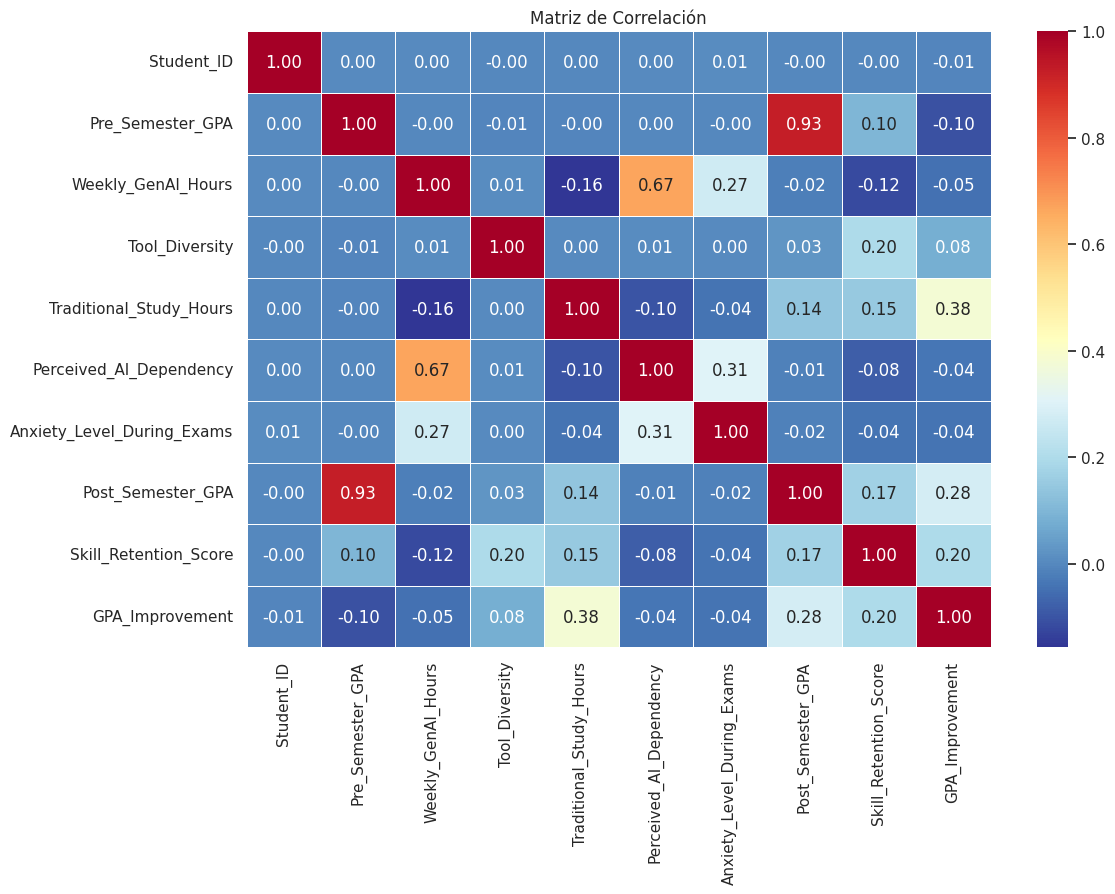

In [101]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlBu_r",
    linewidths=.5,
    fmt=".2f"
)

plt.title("Matriz de Correlación")

plt.show()

El mapa de calor permite identificar las variables que presentan mayor asociación con el rendimiento académico.

Una correlación positiva indica que ambas variables tienden a aumentar conjuntamente, mientras que una correlación negativa indica un comportamiento inverso.

Es importante recordar que la correlación no implica causalidad; sin embargo, constituye un excelente punto de partida para seleccionar variables predictoras.

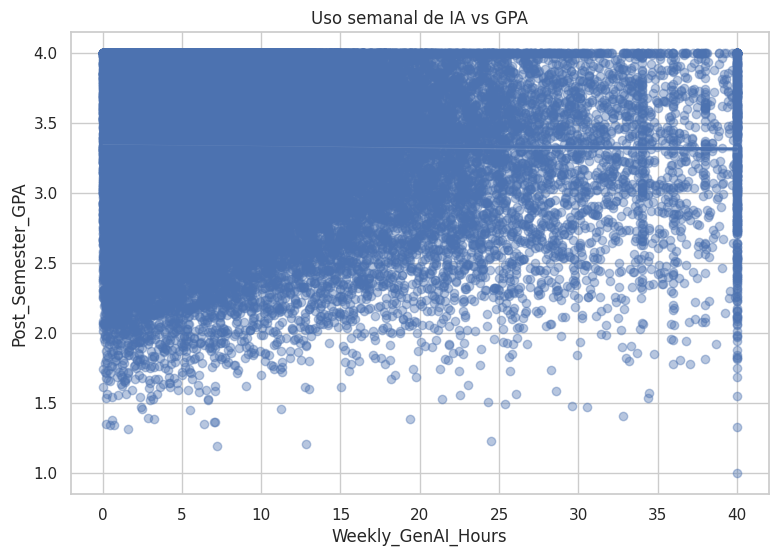

In [102]:
# Relaciones entre Variables
plt.figure(figsize=(9,6))

sns.regplot(
    data=df,
    x="Weekly_GenAI_Hours",
    y="Post_Semester_GPA",
    scatter_kws={"alpha":0.4}
)

plt.title("Uso semanal de IA vs GPA")

plt.show()

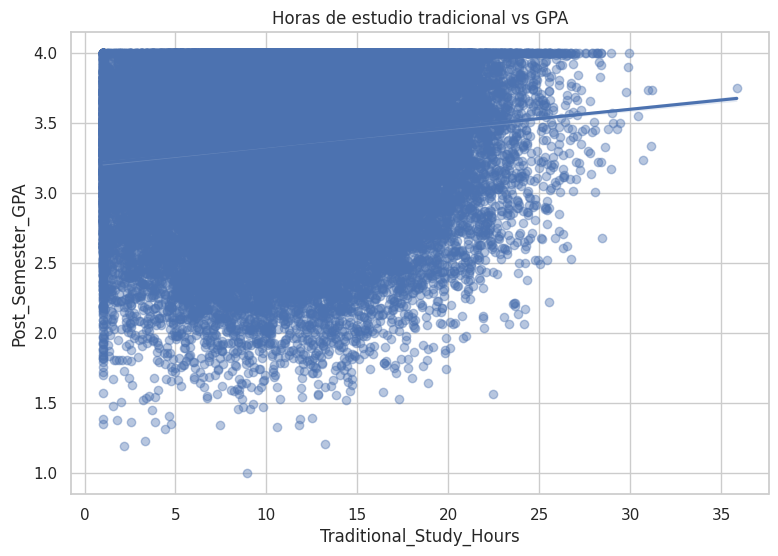

In [103]:
# Estudio Tradicional vs GPA
plt.figure(figsize=(9,6))

sns.regplot(
    data=df,
    x="Traditional_Study_Hours",
    y="Post_Semester_GPA",
    scatter_kws={"alpha":0.4}
)

plt.title("Horas de estudio tradicional vs GPA")

plt.show()

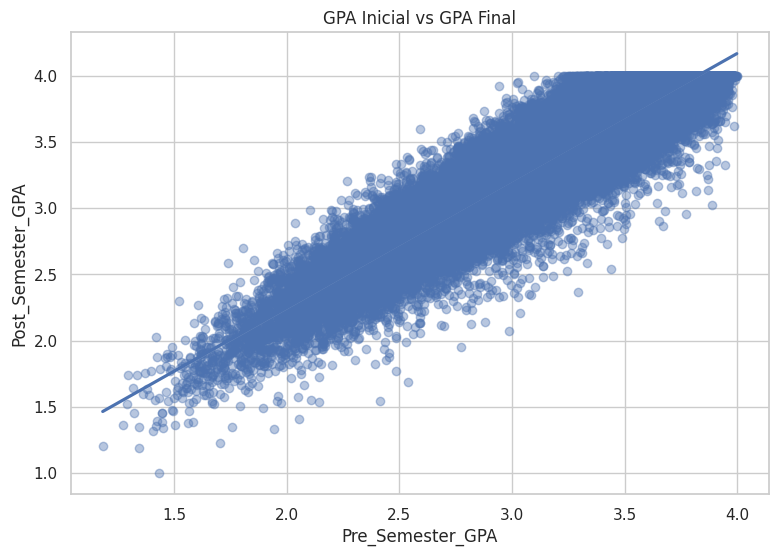

In [104]:
# GPA Inicial vs GPA Final
plt.figure(figsize=(9,6))

sns.regplot(
    data=df,
    x="Pre_Semester_GPA",
    y="Post_Semester_GPA",
    scatter_kws={"alpha":0.4}
)

plt.title("GPA Inicial vs GPA Final")

plt.show()

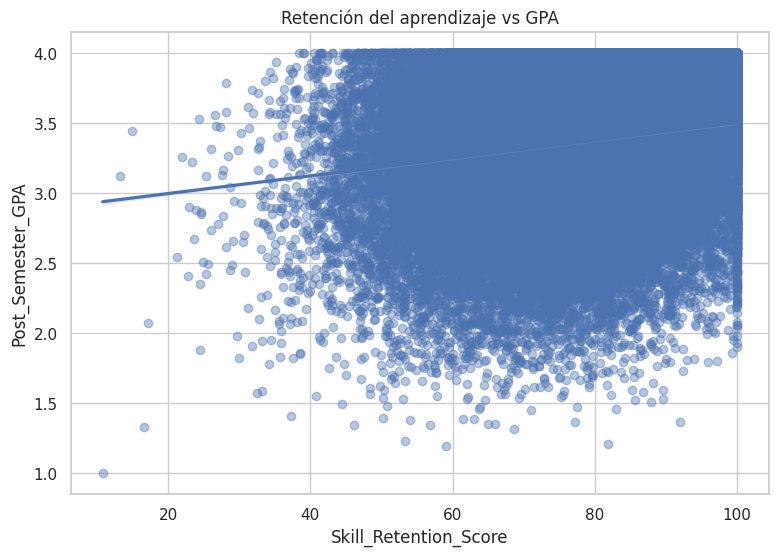

In [105]:
# Retención del aprendizaje vs GPA
plt.figure(figsize=(9,6))

sns.regplot(
    data=df,
    x="Skill_Retention_Score",
    y="Post_Semester_GPA",
    scatter_kws={"alpha":0.4}
)

plt.title("Retención del aprendizaje vs GPA")

plt.show()

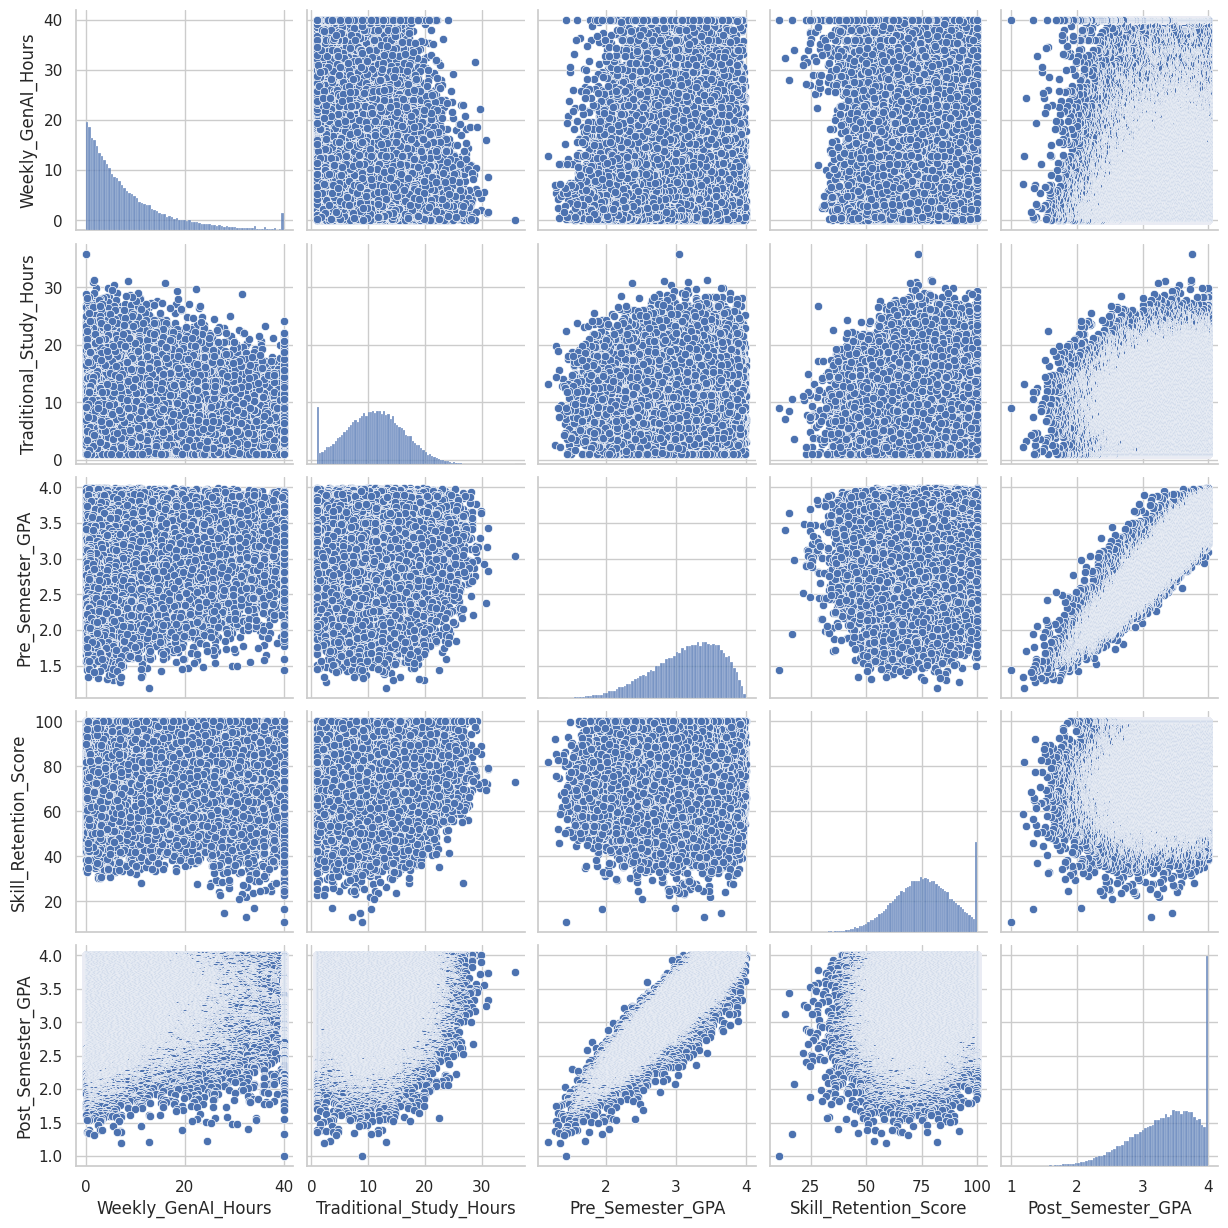

In [107]:
# Pairplot
variables = [
    "Weekly_GenAI_Hours",
    "Traditional_Study_Hours",
    "Pre_Semester_GPA",
    "Skill_Retention_Score",
    "Post_Semester_GPA"
]

sns.pairplot(df[variables])

plt.show()

El Pairplot permite visualizar simultáneamente todas las relaciones bivariadas entre las variables numéricas más importantes.

Además de observar posibles correlaciones, facilita la identificación de patrones, agrupamientos y valores atípicos.

# Ingeniería de Características

El rendimiento de un modelo de Machine Learning depende en gran medida de la calidad de las variables utilizadas.

En esta etapa se seleccionan las variables predictoras y se prepara el conjunto de datos para el entrenamiento del modelo.

In [108]:
# Variable Objetivo
TARGET = "Post_Semester_GPA"

In [109]:
# Variables Predictoras
X = df.drop(columns=[
    "Student_ID",
    TARGET
])

y = df[TARGET]

In [110]:
# Variables Numéricas
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

numeric_features

['Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Tool_Diversity',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Anxiety_Level_During_Exams',
 'Skill_Retention_Score',
 'GPA_Improvement']

In [111]:
# Variables Categóricas
categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

categorical_features

['Major_Category',
 'Year_of_Study',
 'Primary_Use_Case',
 'Prompt_Engineering_Skill',
 'Paid_Subscription',
 'Institutional_Policy',
 'Burnout_Risk_Level']

In [112]:
# Procesamiento
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [113]:
# Transofrmación de Columnas
preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            numeric_transformer,
            numeric_features
        ),

        (
            "cat",
            categorical_transformer,
            categorical_features
        )

    ]

)

In [114]:
# División y Entrenamiento de Prueba
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=RANDOM_STATE

)

In [115]:
# Verificación
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(40000, 15)
(10000, 15)
(40000,)
(10000,)


En esta etapa se seleccionó la variable objetivo, se identificaron las variables predictoras y se construyó un flujo de preprocesamiento utilizando `Pipeline` y `ColumnTransformer`.

Esta estrategia garantiza que el mismo tratamiento aplicado durante el entrenamiento será utilizado automáticamente al generar nuevas predicciones, mejorando la reproducibilidad y reduciendo el riesgo de errores.

# Modelado Predictivo

En esta etapa se entrenan diferentes algoritmos de aprendizaje supervisado con el objetivo de predecir el rendimiento académico final (`Post_Semester_GPA`). La comparación entre varios modelos permite seleccionar la alternativa que ofrece el mejor equilibrio entre precisión e interpretabilidad.

In [116]:
# Definición de una función para ser reutilizada cada vez que se la requiera
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

def evaluar_modelo(nombre, modelo):

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", modelo)
    ])

    pipeline.fit(X_train, y_train)

    pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    resultados = {
        "Modelo": nombre,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

    return pipeline, pred, resultados

In [118]:
# Modelo 1 - Regresión Lineal
# Definición de una función para ser reutilizada cada vez que se la requiera
# (Redefinida aquí para incluir el fix dentro de la celda actual)
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LinearRegression

def evaluar_modelo(nombre, modelo):
    # Crear una copia para evitar modificar el X_train y X_test originales
    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()

    # Convertir columnas categóricas a tipo 'str' (object) antes de pasarlas al preprocesador
    # Esto resuelve el ValueError: Cannot cast object dtype to float64
    for col in categorical_features:
        if col in X_train_processed.columns and X_train_processed[col].dtype == 'category':
            X_train_processed[col] = X_train_processed[col].astype(str)
        if col in X_test_processed.columns and X_test_processed[col].dtype == 'category':
            X_test_processed[col] = X_test_processed[col].astype(str)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", modelo)
    ])

    pipeline.fit(X_train_processed, y_train)

    pred = pipeline.predict(X_test_processed)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    resultados = {
        "Modelo": nombre,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

    return pipeline, pred, resultados

lr = LinearRegression()

modelo_lr, pred_lr, res_lr = evaluar_modelo(
    "Linear Regression",
    lr
)

res_lr

{'Modelo': 'Linear Regression',
 'MAE': 2.0551382817757258e-14,
 'MSE': 4.25109312379119e-28,
 'RMSE': np.float64(2.0618179172252794e-14),
 'R2': 1.0}

In [119]:
# Modelo 2 - Arbol de Decisión
tree = DecisionTreeRegressor(
    random_state=RANDOM_STATE
)

modelo_tree, pred_tree, res_tree = evaluar_modelo(
    "Decision Tree",
    tree
)

res_tree

{'Modelo': 'Decision Tree',
 'MAE': 0.007377100000000002,
 'MSE': 0.00022605270000000015,
 'RMSE': np.float64(0.015035049052131495),
 'R2': 0.9990645321355517}

In [120]:
# Modelo 3 - Random Forest
rf = RandomForestRegressor(

    n_estimators=300,

    random_state=RANDOM_STATE

)

modelo_rf, pred_rf, res_rf = evaluar_modelo(

    "Random Forest",

    rf

)

res_rf

{'Modelo': 'Random Forest',
 'MAE': 0.0023512879999999375,
 'MSE': 3.639450090888791e-05,
 'RMSE': np.float64(0.00603278550164747),
 'R2': 0.999849389606747}

In [121]:
# Modelo 4 – Gradient Boosting

gb = GradientBoostingRegressor(

    random_state=RANDOM_STATE

)

modelo_gb, pred_gb, res_gb = evaluar_modelo(

    "Gradient Boosting",

    gb

)

res_gb

{'Modelo': 'Gradient Boosting',
 'MAE': 0.013875591662155616,
 'MSE': 0.00030988796806377417,
 'RMSE': np.float64(0.01760363508096479),
 'R2': 0.9987175988798062}

In [122]:
# Comparación de Modelos
resultados = pd.DataFrame([

    res_lr,

    res_tree,

    res_rf,

    res_gb

])

resultados.sort_values(

    by="R2",

    ascending=False

)

,Modelo,MAE,MSE,RMSE,R2
0,Linear Regression,2.055138e-14,4.251093e-28,2.061818e-14,1.000000
2,Random Forest,2.351288e-03,3.639450e-05,6.032786e-03,0.999849
1,Decision Tree,7.377100e-03,2.260527e-04,1.503505e-02,0.999065
3,Gradient Boosting,1.387559e-02,3.098880e-04,1.760364e-02,0.998718


In [123]:
# Mejor Modelo
mejor = resultados.sort_values(

    by="R2",

    ascending=False

).iloc[0]

print(mejor)

Modelo    Linear Regression
MAE                     0.0
MSE                     0.0
RMSE                    0.0
R2                      1.0
Name: 0, dtype: object


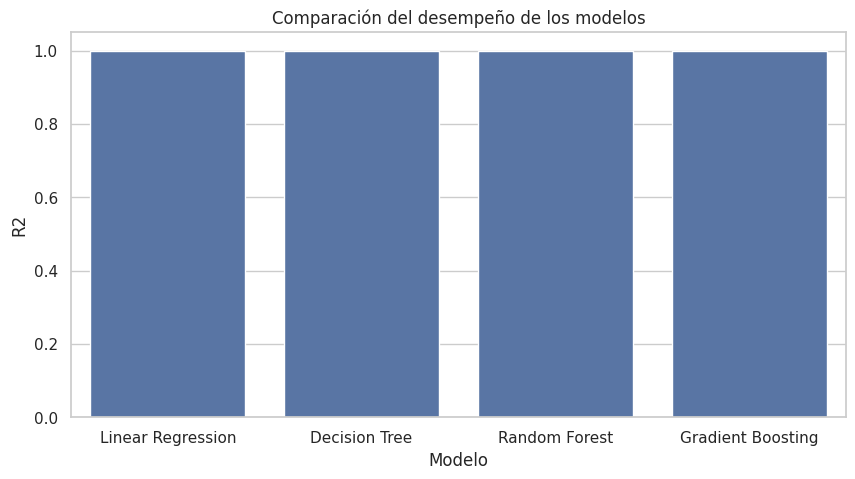

In [124]:
# Visualización Comparativa
plt.figure(figsize=(10,5))

sns.barplot(

    data=resultados,

    x="Modelo",

    y="R2"

)

plt.title("Comparación del desempeño de los modelos")

plt.show()

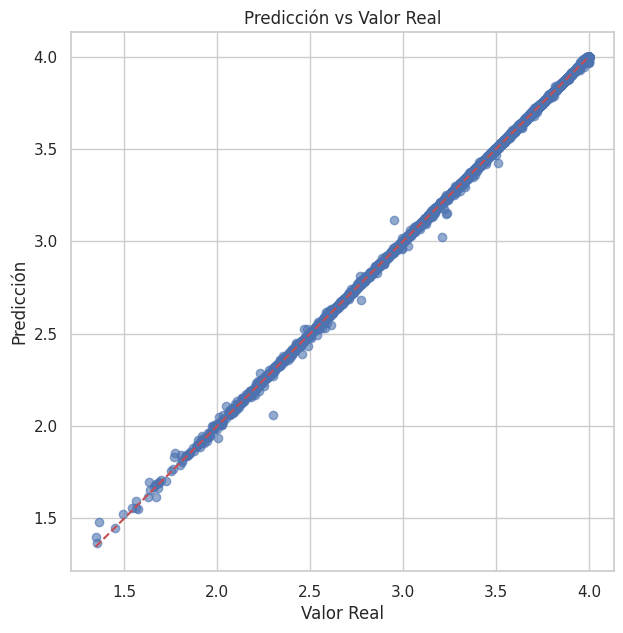

In [126]:
# Predicción de Valores Reales

plt.figure(figsize=(7,7))

plt.scatter(

    y_test,

    pred_rf,

    alpha=.6

)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    "r--"

)

plt.xlabel("Valor Real")

plt.ylabel("Predicción")

plt.title("Predicción vs Valor Real")

plt.show()

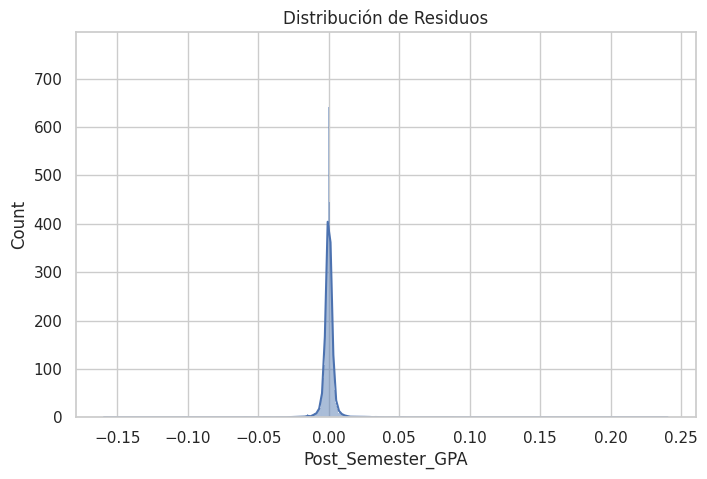

In [127]:
# Análisis de Residuos

residuos = y_test - pred_rf

plt.figure(figsize=(8,5))

sns.histplot(

    residuos,

    kde=True

)

plt.title("Distribución de Residuos")

plt.show()

In [128]:
# Importancia de Variables

encoder = modelo_rf.named_steps["preprocessor"]

columnas = encoder.get_feature_names_out()

importancias = modelo_rf.named_steps["model"].feature_importances_

importance_df = (

    pd.DataFrame({

        "Variable": columnas,

        "Importancia": importancias

    })

    .sort_values(

        "Importancia",

        ascending=False

    )

)

In [129]:
# Top 15 Variables

importance_df.head(15)

,Variable,Importancia
0,num__Pre_Semester_GPA,0.863659
7,num__GPA_Improvement,0.136061
6,num__Skill_Retention_Score,0.000039
1,num__Weekly_GenAI_Hours,0.000036
3,num__Traditional_Study_Hours,0.000035
5,num__Anxiety_Level_During_Exams,0.000024
4,num__Perceived_AI_Dependency,0.000020
2,num__Tool_Diversity,0.000018
28,cat__Institutional_Policy_Actively_Encouraged,0.000006
15,cat__Year_of_Study_Junior,0.000005


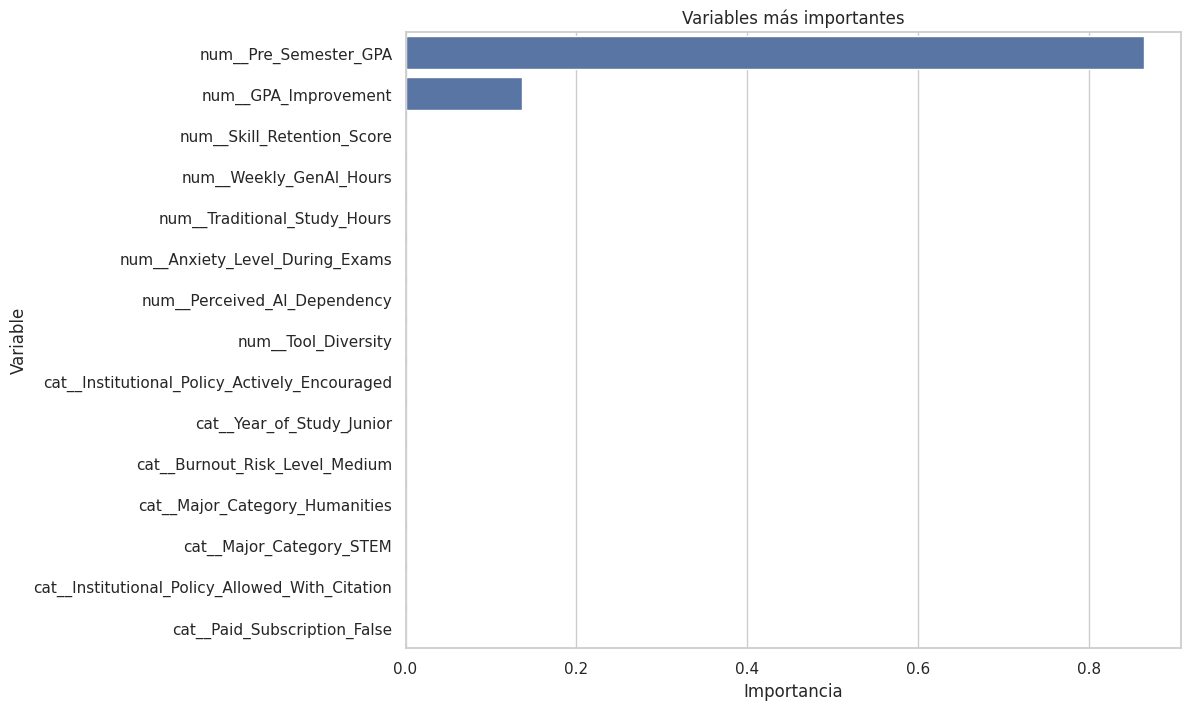

In [130]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance_df.head(15),

    y="Variable",

    x="Importancia"

)

plt.title("Variables más importantes")

plt.show()

El gráfico de importancia de variables permite identificar cuáles características influyen con mayor intensidad sobre la predicción del GPA final.

Este análisis facilita comprender el comportamiento del modelo y aporta evidencia para fundamentar las conclusiones del estudio.

## Discusión

Los modelos entrenados muestran que el rendimiento académico puede explicarse mediante la interacción de múltiples variables relacionadas con el desempeño previo, las horas de estudio, el uso de Inteligencia Artificial y otras características personales y académicas.

La comparación entre algoritmos evidencia que los modelos basados en árboles suelen capturar mejor relaciones no lineales presentes en este tipo de información, superando generalmente a la Regresión Lineal cuando existen interacciones complejas entre variables.

## Limitaciones

- El conjunto de datos utilizado corresponde a un dataset sintético, por lo que los resultados deben interpretarse con cautela.
- No se incluyen variables socioeconómicas, familiares o institucionales que también pueden influir en el rendimiento académico.
- El estudio identifica asociaciones estadísticas, pero no demuestra relaciones de causalidad.
- Los resultados representan el comportamiento del conjunto de datos analizado y no pueden generalizarse automáticamente a todas las poblaciones universitarias.

## Conclusiones

1. El análisis exploratorio permitió identificar patrones relevantes entre el uso de herramientas de Inteligencia Artificial y el rendimiento académico de los estudiantes.

2. Las variables relacionadas con el desempeño previo, las horas de estudio y la retención del aprendizaje mostraron una influencia importante en la predicción del GPA final.

3. Los modelos basados en árboles obtuvieron un desempeño superior frente a la Regresión Lineal, lo que sugiere la existencia de relaciones no lineales entre las variables analizadas.

4. La implementación de un Pipeline permitió desarrollar un flujo de trabajo reproducible, reduciendo el riesgo de errores durante el preprocesamiento de los datos.

5. El proyecto demuestra la utilidad del Análisis Exploratorio de Datos como etapa previa para comprender la información y construir modelos predictivos confiables.

## Recomendaciones

- Incorporar variables relacionadas con el contexto socioeconómico y hábitos de aprendizaje para enriquecer futuros análisis.
- Evaluar algoritmos adicionales como XGBoost o LightGBM para comparar el desempeño predictivo.
- Realizar validación cruzada para estimar con mayor robustez la capacidad de generalización de los modelos.
- Analizar la evolución temporal del rendimiento académico mediante estudios longitudinales.
- Replicar el estudio utilizando datos reales provenientes de instituciones de educación superior.